In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
surabaya_df = pd.read_excel("https://github.com/adriann03/BigData/raw/refs/heads/main/data/Data%20Curah%20Hujan%20Surabaya%202025.xlsx")
banyuwangi_df = pd.read_excel("https://github.com/adriann03/BigData/raw/refs/heads/main/data/Data%20Curah%20Hujan%20Banyuwangi%202025.xlsx")

print("DF Surabaya")
display(surabaya_df)
print()
print("DF Banyuwangi")
display(banyuwangi_df)

DF Surabaya


,TANGGAL,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,DDD_X,FF_AVG,DDD_CAR
0,01-01-2025,26.2,31.8,28.0,82,8.5,2.0,4,320,2,NW
1,02-01-2025,25.0,32.4,27.1,89,36.2,0.0,4,340,1,N
2,03-01-2025,25.6,34.6,29.3,74,0.6,1.4,3,300,2,NW
3,04-01-2025,26.0,33.8,29.2,73,0.0,7.5,6,350,3,NW
4,05-01-2025,25.9,33.8,27.8,81,6.8,3.8,6,310,2,S
...,...,...,...,...,...,...,...,...,...,...,...
360,27-12-2025,26.1,33.8,29.3,74,0.5,7.5,7,270,3,NW
361,28-12-2025,25.0,34.4,28.8,81,23.6,1.7,5,290,2,NW
362,29-12-2025,26.2,34.0,29.6,78,8888.0,8.0,8,160,3,NE
363,30-12-2025,25.2,32.4,29.3,75,4.8,8.0,4,350,2,N



DF Banyuwangi


,Tanggal,TN,TX,TAVG,RH_AVG,RR,SS
0,01-01-2025,26.1,29.9,27.6,84,8888.0,0.3
1,02-01-2025,24.9,29.7,26.5,87,5.0,0.6
2,03-01-2025,24.2,31.2,27.4,78,5.6,0.2
3,04-01-2025,24.7,31.1,26.3,83,2.2,2.3
4,05-01-2025,24.1,31.0,28.3,75,1.6,2.7
...,...,...,...,...,...,...,...
360,27-12-2025,25.7,34.0,29.8,67,0.0,4.1
361,28-12-2025,25.3,32.9,28.4,76,0.0,3.5
362,29-12-2025,24.7,32.4,29.0,73,14.6,6.5
363,30-12-2025,24.3,32.0,27.7,74,0.0,6.5


In [ ]:
surabaya_df.drop(["FF_X", "DDD_X", "FF_AVG", "DDD_CAR"], axis=1, inplace=True)

In [ ]:
surabaya_df.info()
banyuwangi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TANGGAL  365 non-null    object 
 1   TN       365 non-null    float64
 2   TX       365 non-null    float64
 3   TAVG     365 non-null    float64
 4   RH_AVG   365 non-null    int64  
 5   RR       365 non-null    float64
 6   SS       365 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 20.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Tanggal  365 non-null    object 
 1   TN       365 non-null    float64
 2   TX       365 non-null    float64
 3   TAVG     365 non-null    float64
 4   RH_AVG   365 non-null    int64  
 5   RR       365 non-null    float64
 6   SS       365 non-null    float64
dtypes: float64(5), int64(1), object(1)
memor

In [ ]:
surabaya_df.replace(8888, 0, inplace=True)
surabaya_df.replace(9999, 0, inplace=True)
display(surabaya_df)

banyuwangi_df.replace(8888, 0, inplace=True)
banyuwangi_df.replace(9999, 0, inplace=True)
display(banyuwangi_df)

,TANGGAL,TN,TX,TAVG,RH_AVG,RR,SS
0,01-01-2025,26.2,31.8,28.0,82,8.5,2.0
1,02-01-2025,25.0,32.4,27.1,89,36.2,0.0
2,03-01-2025,25.6,34.6,29.3,74,0.6,1.4
3,04-01-2025,26.0,33.8,29.2,73,0.0,7.5
4,05-01-2025,25.9,33.8,27.8,81,6.8,3.8
...,...,...,...,...,...,...,...
360,27-12-2025,26.1,33.8,29.3,74,0.5,7.5
361,28-12-2025,25.0,34.4,28.8,81,23.6,1.7
362,29-12-2025,26.2,34.0,29.6,78,0.0,8.0
363,30-12-2025,25.2,32.4,29.3,75,4.8,8.0


,Tanggal,TN,TX,TAVG,RH_AVG,RR,SS
0,01-01-2025,26.1,29.9,27.6,84,0.0,0.3
1,02-01-2025,24.9,29.7,26.5,87,5.0,0.6
2,03-01-2025,24.2,31.2,27.4,78,5.6,0.2
3,04-01-2025,24.7,31.1,26.3,83,2.2,2.3
4,05-01-2025,24.1,31.0,28.3,75,1.6,2.7
...,...,...,...,...,...,...,...
360,27-12-2025,25.7,34.0,29.8,67,0.0,4.1
361,28-12-2025,25.3,32.9,28.4,76,0.0,3.5
362,29-12-2025,24.7,32.4,29.0,73,14.6,6.5
363,30-12-2025,24.3,32.0,27.7,74,0.0,6.5


In [ ]:
surabaya_df['TANGGAL'] = pd.to_datetime(surabaya_df['TANGGAL'], format='%d-%m-%Y')
banyuwangi_df['Tanggal'] = pd.to_datetime(banyuwangi_df['Tanggal'], format='%d-%m-%Y')

surabaya_df['Bulan'] = surabaya_df['TANGGAL'].dt.month
banyuwangi_df['Bulan'] = banyuwangi_df['Tanggal'].dt.month

curah_hujan_surabaya_bulan = surabaya_df.groupby('Bulan')['RR'].sum().reset_index()
curah_hujan_banyuwangi_bulan = banyuwangi_df.groupby('Bulan')['RR'].sum().reset_index()

print("Curah Hujan Bulanan Surabaya:")
print(curah_hujan_surabaya_bulan)
print("\nCurah Hujan Bulanan Banyuwangi:")
print(curah_hujan_banyuwangi_bulan)

Curah Hujan Bulanan Surabaya:
    Bulan     RR
0       1  487.5
1       2  157.6
2       3  178.2
3       4   94.5
4       5   53.4
5       6   53.1
6       7   58.0
7       8   26.5
8       9    7.6
9      10   82.3
10     11  415.2
11     12  285.6

Curah Hujan Bulanan Banyuwangi:
    Bulan     RR
0       1  281.1
1       2  164.6
2       3  319.6
3       4  116.4
4       5   81.0
5       6   41.4
6       7   51.8
7       8   48.6
8       9  132.4
9      10    5.0
10     11  234.0
11     12  165.2


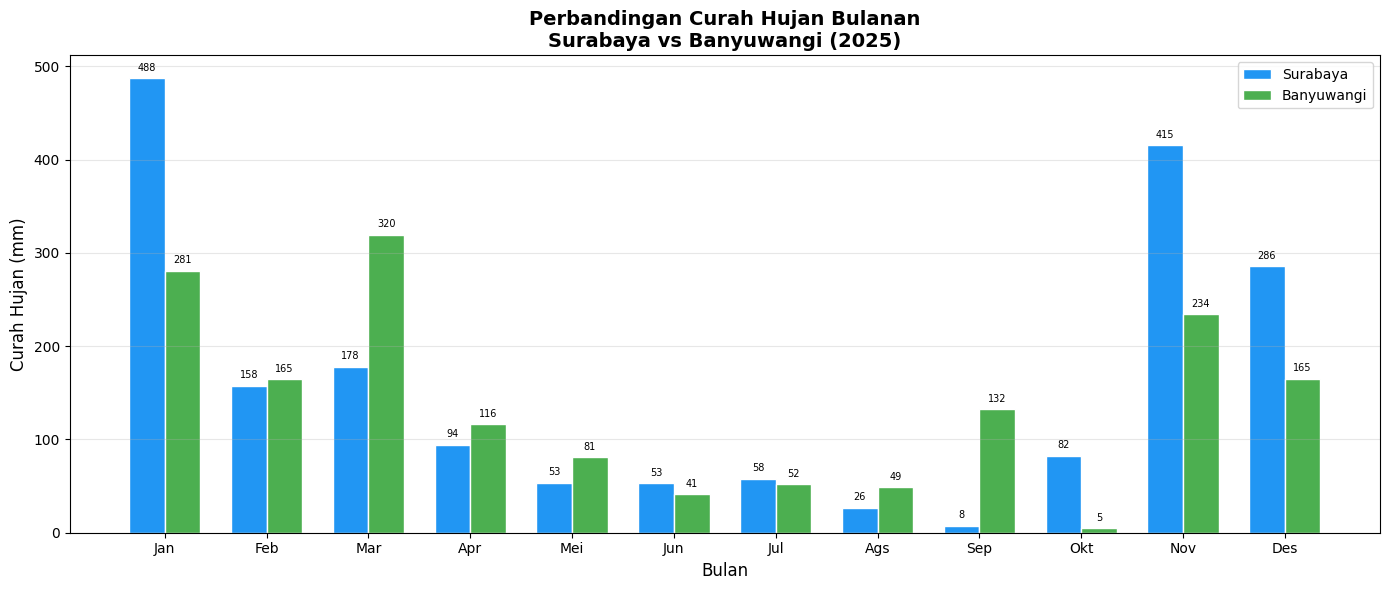

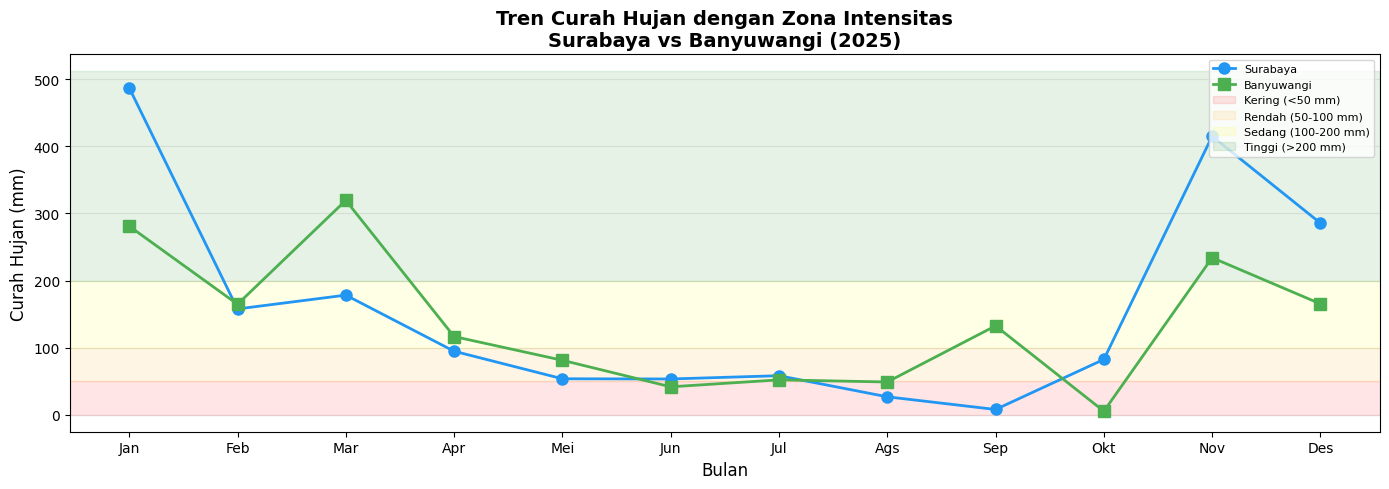

In [ ]:
# =============================================
# VISUALISASI PERBANDINGAN CURAH HUJAN BULANAN
# =============================================

nama_bulan = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun',
              'Jul', 'Ags', 'Sep', 'Okt', 'Nov', 'Des']

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(nama_bulan))
width = 0.35

bars1 = ax.bar(x - width/2, curah_hujan_surabaya_bulan['RR'], width,
               label='Surabaya', color='#2196F3', edgecolor='white')
bars2 = ax.bar(x + width/2, curah_hujan_banyuwangi_bulan['RR'], width,
               label='Banyuwangi', color='#4CAF50', edgecolor='white')

# Tambah label angka di atas bar
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.0f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', fontsize=7)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.0f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', fontsize=7)

ax.set_xlabel('Bulan', fontsize=12)
ax.set_ylabel('Curah Hujan (mm)', fontsize=12)
ax.set_title('Perbandingan Curah Hujan Bulanan\nSurabaya vs Banyuwangi (2025)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(nama_bulan)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================
# LINE CHART - TREN CURAH HUJAN
# =============================================

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(x, curah_hujan_surabaya_bulan['RR'], marker='o', linewidth=2,
        label='Surabaya', color='#2196F3', markersize=8)
ax.plot(x, curah_hujan_banyuwangi_bulan['RR'], marker='s', linewidth=2,
        label='Banyuwangi', color='#4CAF50', markersize=8)

# Zona musim
ax.axhspan(0, 50, alpha=0.1, color='red', label='Kering (<50 mm)')
ax.axhspan(50, 100, alpha=0.1, color='orange', label='Rendah (50-100 mm)')
ax.axhspan(100, 200, alpha=0.1, color='yellow', label='Sedang (100-200 mm)')
ax.axhspan(200, ax.get_ylim()[1] if ax.get_ylim()[1] > 200 else 400,
           alpha=0.1, color='green', label='Tinggi (>200 mm)')

ax.set_xlabel('Bulan', fontsize=12)
ax.set_ylabel('Curah Hujan (mm)', fontsize=12)
ax.set_title('Tren Curah Hujan dengan Zona Intensitas\nSurabaya vs Banyuwangi (2025)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(nama_bulan)
ax.legend(loc='upper right', fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

TABEL KESESUAIAN CURAH HUJAN UNTUK TANAMAN PANGAN - BANYUWANGI 2025

Threshold kebutuhan air:
  Padi      : 100-200 mm/bulan
  Jagung    : 50-100 mm/bulan
  Kedelai   : 80-150 mm/bulan



,Bulan,CH (mm),Padi,Jagung,Kedelai
0,Jan,281.1,Berlebih,Berlebih,Berlebih
1,Feb,164.6,Optimal,Berlebih,Berlebih
2,Mar,319.6,Berlebih,Berlebih,Berlebih
3,Apr,116.4,Optimal,Berlebih,Optimal
4,Mei,81.0,Kurang,Optimal,Optimal
5,Jun,41.4,Sangat Kritis,Kurang,Kurang
6,Jul,51.8,Kurang,Optimal,Kurang
7,Ags,48.6,Sangat Kritis,Kurang,Kurang
8,Sep,132.4,Optimal,Berlebih,Optimal
9,Okt,5.0,Sangat Kritis,Sangat Kritis,Sangat Kritis


/tmp/ipykernel_6624/711228794.py:57: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_data = df_kesesuaian[['Padi', 'Jagung', 'Kedelai']].replace(mapping).values.T


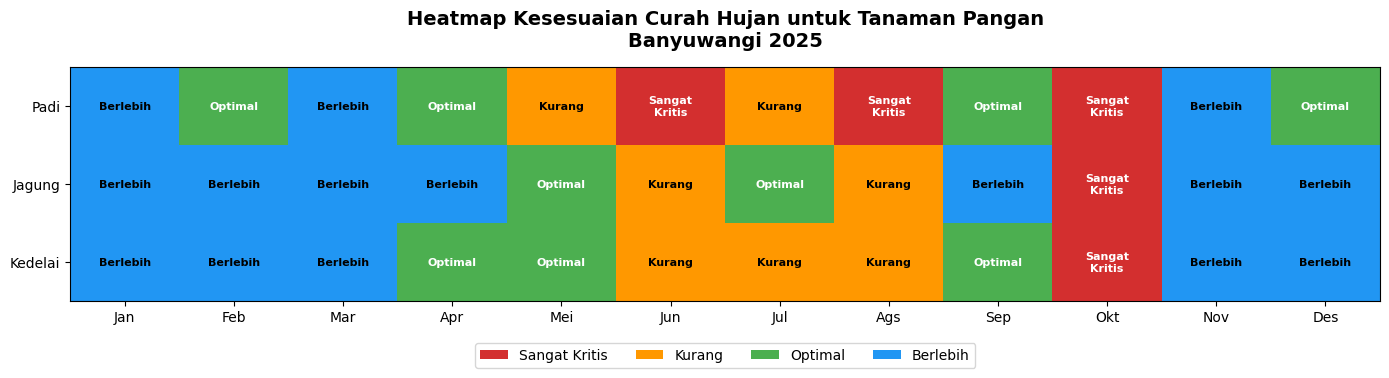

In [ ]:
# =============================================
# ANALISIS KESESUAIAN TANAM - BANYUWANGI
# =============================================

# Threshold kebutuhan air tanaman (mm/bulan)
kebutuhan_tanaman = {
    'Padi': {'min': 100, 'max': 200},
    'Jagung': {'min': 50, 'max': 100},
    'Kedelai': {'min': 80, 'max': 150}
}

nama_bulan = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun',
              'Jul', 'Ags', 'Sep', 'Okt', 'Nov', 'Des']

# Fungsi klasifikasi kesesuaian
def klasifikasi_kesesuaian(ch, min_val, max_val):
    if ch < min_val * 0.5:
        return 'Sangat Kritis'
    elif ch < min_val:
        return 'Kurang'
    elif ch <= max_val:
        return 'Optimal'
    else:
        return 'Berlebih'

# Buat tabel kesesuaian
data_kesesuaian = []
for i, row in curah_hujan_banyuwangi_bulan.iterrows():
    bulan = nama_bulan[int(row['Bulan']) - 1]
    ch = row['RR']
    entry = {'Bulan': bulan, 'CH (mm)': round(ch, 1)}

    for tanaman, threshold in kebutuhan_tanaman.items():
        entry[tanaman] = klasifikasi_kesesuaian(ch, threshold['min'], threshold['max'])

    data_kesesuaian.append(entry)

df_kesesuaian = pd.DataFrame(data_kesesuaian)
print("=" * 70)
print("TABEL KESESUAIAN CURAH HUJAN UNTUK TANAMAN PANGAN - BANYUWANGI 2025")
print("=" * 70)
print(f"\nThreshold kebutuhan air:")
for tanaman, th in kebutuhan_tanaman.items():
    print(f"  {tanaman:10s}: {th['min']}-{th['max']} mm/bulan")
print()
display(df_kesesuaian)

# =============================================
# HEATMAP KESESUAIAN TANAM
# =============================================

# Mapping ke angka untuk heatmap
mapping = {'Sangat Kritis': 0, 'Kurang': 1, 'Optimal': 2, 'Berlebih': 3}
label_map = {0: 'Sangat\nKritis', 1: 'Kurang', 2: 'Optimal', 3: 'Berlebih'}
color_map = ['#D32F2F', '#FF9800', '#4CAF50', '#2196F3']

heatmap_data = df_kesesuaian[['Padi', 'Jagung', 'Kedelai']].replace(mapping).values.T

fig, ax = plt.subplots(figsize=(14, 4))
cmap = plt.cm.colors.ListedColormap(color_map)

im = ax.imshow(heatmap_data, cmap=cmap, aspect='auto', vmin=-0.5, vmax=3.5)

# Label di setiap cell
tanaman_list = ['Padi', 'Jagung', 'Kedelai']
for i in range(len(tanaman_list)):
    for j in range(len(nama_bulan)):
        val = heatmap_data[i, j]
        text_color = 'white' if val in [0, 2] else 'black'
        ax.text(j, i, label_map[val], ha='center', va='center',
                fontsize=8, fontweight='bold', color=text_color)

ax.set_xticks(range(len(nama_bulan)))
ax.set_xticklabels(nama_bulan)
ax.set_yticks(range(len(tanaman_list)))
ax.set_yticklabels(tanaman_list)
ax.set_title('Heatmap Kesesuaian Curah Hujan untuk Tanaman Pangan\nBanyuwangi 2025',
             fontsize=14, fontweight='bold', pad=15)

# Legend manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l.replace('\n', ' '))
                   for c, l in zip(color_map, ['Sangat Kritis', 'Kurang', 'Optimal', 'Berlebih'])]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.15),
          ncol=4, fontsize=10)

plt.tight_layout()
plt.show()

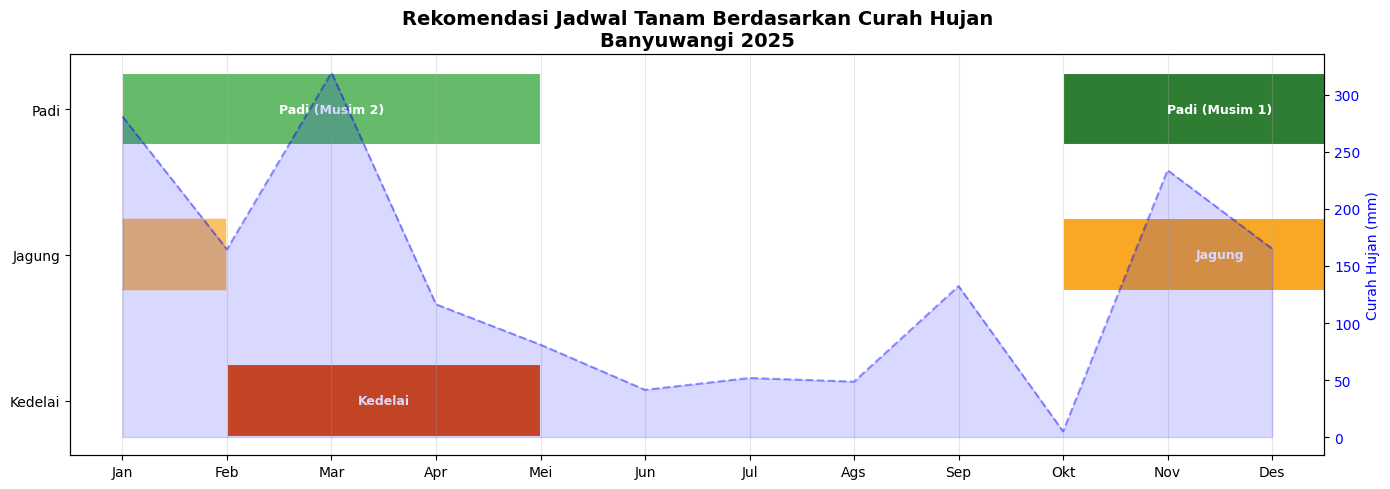

KESIMPULAN ANALISIS CURAH HUJAN & REKOMENDASI TANAM
Banyuwangi 2025

POLA CURAH HUJAN:
  - Musim Hujan   : November - April (curah hujan > 100 mm/bulan)
  - Musim Kemarau : Mei - Oktober (curah hujan < 100 mm/bulan)
  - Bulan terkering: Oktober (sangat ekstrem)
  - Bulan terbasah : Januari & Maret

REKOMENDASI JADWAL TANAM:

  1. PADI (butuh 100-200 mm/bulan)
     - Musim Tanam 1 : November - Desember (panen Maret-April)
     - Musim Tanam 2 : Februari - Maret (panen Juni-Juli, butuh irigasi)
     - HINDARI tanam Mei-Oktober tanpa irigasi

  2. JAGUNG (butuh 50-100 mm/bulan)
     - Waktu optimal : November - Januari
     - Alternatif    : Maret - April (manfaatkan sisa musim hujan)
     - Lebih toleran kekeringan dibanding padi

  3. KEDELAI (butuh 80-150 mm/bulan)
     - Waktu optimal : Maret - April (akhir musim hujan)
     - Alternatif    : November (awal musim hujan)
     - HINDARI Juni - Oktober (kekeringan berat)

PERBANDINGAN SURABAYA vs BANYUWANGI:
  - Pola musiman serupa (sama

In [ ]:
# =============================================
# REKOMENDASI JADWAL TANAM & KESIMPULAN
# =============================================

# Timeline visual rekomendasi tanam
fig, ax = plt.subplots(figsize=(14, 5))

rekomendasi = {
    'Padi (Musim 1)':   {'start': 10, 'end': 14, 'color': '#2E7D32', 'y': 3},   # Nov-Feb (panen Mar)
    'Padi (Musim 2)':   {'start': 1,  'end': 5,  'color': '#66BB6A', 'y': 3},    # Feb-Mei (panen Jun)
    'Jagung':           {'start': 10, 'end': 13, 'color': '#F9A825', 'y': 2},     # Nov-Jan
    'Kedelai':          {'start': 2,  'end': 5,  'color': '#E65100', 'y': 1},     # Mar-Mei
}

for tanaman, info in rekomendasi.items():
    start = info['start'] - 1
    duration = info['end'] - info['start']
    if info['end'] > 12:  # wrap around (Nov-Feb)
        # Bagian 1: Nov-Des
        ax.barh(info['y'], 12 - start, left=start, height=0.5,
                color=info['color'], edgecolor='white', linewidth=1.5)
        # Bagian 2: Jan-...
        ax.barh(info['y'], info['end'] - 12, left=0, height=0.5,
                color=info['color'], edgecolor='white', linewidth=1.5, alpha=0.7)
        ax.text(start + (12 - start)/2, info['y'], tanaman,
                ha='center', va='center', fontweight='bold', fontsize=9, color='white')
    else:
        ax.barh(info['y'], duration, left=start, height=0.5,
                color=info['color'], edgecolor='white', linewidth=1.5)
        ax.text(start + duration/2, info['y'], tanaman,
                ha='center', va='center', fontweight='bold', fontsize=9, color='white')

# Curah hujan di background
ax2 = ax.twinx()
ch_values = curah_hujan_banyuwangi_bulan['RR'].values
ax2.fill_between(range(12), ch_values, alpha=0.15, color='blue')
ax2.plot(range(12), ch_values, color='blue', alpha=0.4, linewidth=1.5, linestyle='--')
ax2.set_ylabel('Curah Hujan (mm)', fontsize=10, color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

ax.set_xlim(-0.5, 11.5)
ax.set_xticks(range(12))
ax.set_xticklabels(nama_bulan)
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['Kedelai', 'Jagung', 'Padi'])
ax.set_title('Rekomendasi Jadwal Tanam Berdasarkan Curah Hujan\nBanyuwangi 2025',
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================
# RINGKASAN KESIMPULAN
# =============================================

print("=" * 70)
print("KESIMPULAN ANALISIS CURAH HUJAN & REKOMENDASI TANAM")
print("Banyuwangi 2025")
print("=" * 70)

print("""
POLA CURAH HUJAN:
  - Musim Hujan   : November - April (curah hujan > 100 mm/bulan)
  - Musim Kemarau : Mei - Oktober (curah hujan < 100 mm/bulan)
  - Bulan terkering: Oktober (sangat ekstrem)
  - Bulan terbasah : Januari & Maret

REKOMENDASI JADWAL TANAM:

  1. PADI (butuh 100-200 mm/bulan)
     - Musim Tanam 1 : November - Desember (panen Maret-April)
     - Musim Tanam 2 : Februari - Maret (panen Juni-Juli, butuh irigasi)
     - HINDARI tanam Mei-Oktober tanpa irigasi

  2. JAGUNG (butuh 50-100 mm/bulan)
     - Waktu optimal : November - Januari
     - Alternatif    : Maret - April (manfaatkan sisa musim hujan)
     - Lebih toleran kekeringan dibanding padi

  3. KEDELAI (butuh 80-150 mm/bulan)
     - Waktu optimal : Maret - April (akhir musim hujan)
     - Alternatif    : November (awal musim hujan)
     - HINDARI Juni - Oktober (kekeringan berat)

PERBANDINGAN SURABAYA vs BANYUWANGI:
  - Pola musiman serupa (sama-sama Jawa Timur)
  - Banyuwangi umumnya curah hujan lebih tinggi (lebih cocok pertanian)
  - Surabaya lebih urban, data sebagai referensi regional
""")

total_sby = curah_hujan_surabaya_bulan['RR'].sum()
total_bwi = curah_hujan_banyuwangi_bulan['RR'].sum()
print(f"Total Curah Hujan 2025:")
print(f"  Surabaya   : {total_sby:.1f} mm")
print(f"  Banyuwangi : {total_bwi:.1f} mm")